## Overview

We will learn how to work with landcover data and calculate area of different landcover classes in a region. This section also shows how you can scale your analysis to large regions without running into memory limits using `dask`.

## Setup and Data Download

The following blocks of code will install the required packages and download the datasets to your Colab environment.

In [ ]:
%%capture
if 'google.colab' in str(get_ipython()):
    !pip install pystac-client odc-stac rioxarray dask[distributed] \
      jupyter-server-proxy planetary_computer

In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.colors
import pystac_client
from odc import stac
import planetary_computer as pc
import xarray as xr
import rioxarray as rxr
import pyproj
from shapely.geometry import Point
import geopandas as gpd
import pandas as pd
import numpy as np
import dask.array as da


In [ ]:
from dask.distributed import Client
client = Client()  # set up local cluster on the machine
client

If you are running this notebook in Colab, you will need to create and use a proxy URL to see the dashboard running on the local server.

In [ ]:
if 'google.colab' in str(get_ipython()):
    from google.colab import output
    port_to_expose = 8787  # This is the default port for Dask dashboard
    print(output.eval_js(f'google.colab.kernel.proxyPort({port_to_expose})'))


In [ ]:
data_folder = 'data'
output_folder = 'output'

if not os.path.exists(data_folder):
    os.mkdir(data_folder)
if not os.path.exists(output_folder):
    os.mkdir(output_folder)

## Define a Region of Interest

We define a location and choose a circular buffer area as our region of interest.



In [ ]:
latitude = 27.163
longitude = 82.608

Create a GeoDataFrame. This helps us easily convert between CRSs, extract bounds etc.

In [ ]:
point_gdf = gpd.GeoDataFrame(
    data = {'name': ['aoi']},
    geometry=gpd.points_from_xy([longitude], [latitude]),
    crs='EPSG:4326')
point_gdf

To create an accurate buffer, we must first convert the coordinates into a projected CRS. UTM is a good choice for a projected CRS that offers high accuracy with minimal distortions. We can automatically find the appropropriate UTM Zone for the chosen location using `pyproj`.

In [ ]:
# Small bounding box around the chosen coordinates
bbox = (longitude - 0.001, latitude - 0.0001,
        longitude + 0.001, latitude + 0.0001)
aoi = pyproj.aoi.AreaOfInterest(*bbox)

# Query for matching UTM CRS
utm_crs_list = pyproj.database.query_utm_crs_info(
    datum_name='WGS 84',
    area_of_interest=aoi,
)
utm_crs = pyproj.CRS.from_epsg(utm_crs_list[0].code)
print(f'Selected CRS {utm_crs.name}')

Buffer the point.

In [ ]:
buffer_distance_meters = 500

In [ ]:
buffered = point_gdf.to_crs(utm_crs).buffer(buffer_distance_meters)
buffered

## Get ESA WorldCover Data

Let's use [Planetary Computer STAC API](https://planetarycomputer.microsoft.com/docs/quickstarts/reading-stac/) search endpoint to look for items from the ESA WorldCover collection on Azure Blob Storage.

ESA WorldCover has data for year 2020 and 2021. We will use the 2021 data.

In [ ]:
catalog = pystac_client.Client.open(
    'https://planetarycomputer.microsoft.com/api/stac/v1')

# STAC search requires bounding box in EPSG:4326
bounds = buffered.to_crs('EPSG:4326').total_bounds

search = catalog.search(
    collections=['esa-worldcover'],
    bbox=bounds,
    datetime=f'2021',
)
items = search.item_collection()
items

Each STAC item has metadata containing information about the class names, legend colors and pixel values. Let's extract it so we can use it later to contruct a meaningful legend.

In [ ]:
class_list = items[0].assets['map'].extra_fields['classification:classes']
class_dict = {
    c['value']: {'description': c['description'], 'hex': c['color_hint']}
    for c in class_list
}
class_dict

Load the matching images as a XArray Dataset. Accessing data from Planetary Computer is free but requires getting a Shared Access Signature (SAS) token and sign the URLs. The `planetary_computer` Python package provides a simple mechanism for signing the URLs using `sign()` function.

In [ ]:
# Load to XArray
ds = stac.load(
    items,
    bbox=bounds, # <-- load data only for the bbox
    resolution=10,
    crs=utm_crs,
    chunks={},  # <-- use Dask
    patch_url=pc.sign,
    groupby='solar_day',
    preserve_original_order=True
)
ds

The landcover classification data is in the `map` variable. Select it and remove the empty `time` dimension.

In [ ]:
map_data = ds['map'].squeeze()
map_data

Clip the data to the buffered region.

In [ ]:
map_data_clipped = map_data.rio.clip(buffered)

## Visualize the Landcover

To create a meaningful legend, we use the class names and colors from the `class_dict` created earlier.

In [ ]:
colors = ['#000000' for r in range(256)]
for key, value in class_dict.items():
    colors[int(key)] = f'#{value['hex']}'

# Set color for value 0 to transparent
colors[0] = (0, 0, 0, 0)
cmap = matplotlib.colors.ListedColormap(colors)

# Data range is 8-bit (0-255)
normalizer = matplotlib.colors.Normalize(vmin=0, vmax=255)

# Set tick labels
values = [key for key in class_dict]
boundaries = [(values[i + 1] + values[i]) / 2 for i in range(len(values) - 1)]
boundaries = [0] + boundaries + [255]
ticks = [
    (boundaries[i + 1] + boundaries[i]) / 2
    for i in range(len(boundaries) - 1)
]
tick_labels = [
    f'{value['description']} ({key})'
     for key, value in class_dict.items()
]
tick_labels

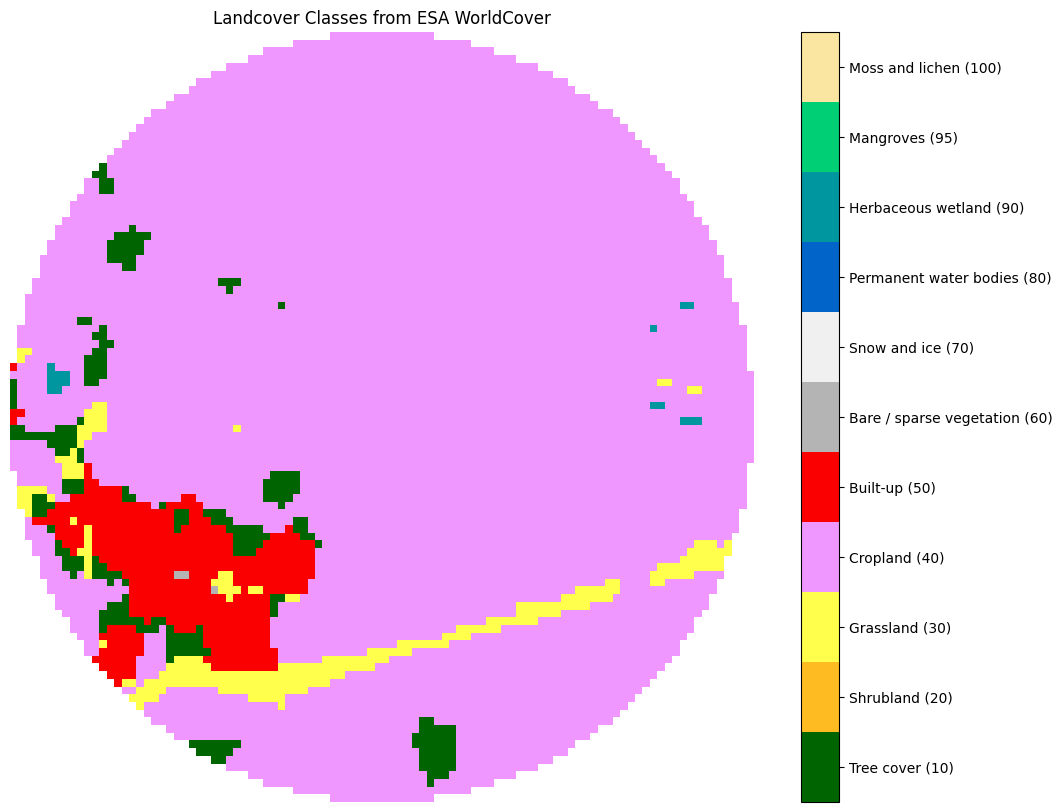

In [27]:
from matplotlib import cm
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1)
fig.set_size_inches(12, 10)

map_data_clipped.plot(
    ax=ax, cmap=cmap, norm=normalizer
)

colorbar = fig.colorbar(
    cm.ScalarMappable(norm=normalizer, cmap=cmap),
    boundaries=boundaries,
    values=values,
    cax=fig.axes[1].axes,
)
colorbar.set_ticks(ticks, labels=tick_labels)

ax.set_axis_off()
ax.set_title('Landcover Classes from ESA WorldCover');

## Exercise

Select a single landcover class and plot it.

Hint: Use the [`where()`](https://docs.xarray.dev/en/stable/generated/xarray.DataArray.where.html) function.

## Calculate Area

We can now calculate are of each class in our region of interest. As our data is in a projected CRS, each pixel's area is fixed. We can count the total number of pixels for each class and multiply it by the area of a single pixel to get the area.

Let's get the underlying array of pixel values.

In [ ]:
data = map_data_clipped.values

To efficiently get the pixel counts of all unique pixel values in the data, we can use `histogram()` function provided by NumPy. The function takes an array of values and returns counts of each pixel value. We need to specify the bins to be used. Since we need counts for each class, we can use the class values as bins.

In [ ]:
# Get unique class values to define histogram bins
unique_classes = sorted(class_dict.keys())
# right edge for last bin
bins = unique_classes + [unique_classes[-1] + 1]

counts, _ = np.histogram(data, bins=bins)
counts

We now have pixel counts of each class. We multiply it by the area of each pixel to get the area. We can also filter out pixels with value 0 (nodata pixels) and counts 0 (not present in the region) to get a clean table.

In [ ]:
pixel_area_m2 = 100.0

area_df = pd.DataFrame({
    'class_value': unique_classes,
    'area_m2': counts * pixel_area_m2,
})

area_df['class_name'] = area_df['class_value'].map(
    lambda x: class_dict[x]['description'])

# Drop nodata class (0) and classes with no pixels
area_df = area_df[
    (area_df['class_value'] != 0) & (area_df['area_m2'] > 0)]

area_df

Save the results as a CSV file.

In [ ]:
output_filename = f'area_{buffer_distance_meters}.csv'
output_filepath = os.path.join(output_folder, output_filename)
area_df.to_csv(output_filepath, index=False)

## Calculating Area for Large Regions

Our previous approach required loading the entire array of landcover classes in the memory using `.values`. If our dataset is very large, this will cause us to run out of memory and result in a crash. We can instead use `dask` to chunk the data which lazily loads each chunk into memory only when processing it.

We update the code from earlier to now specify a large buffer distance for the region of interest and explicitely specify a chunk size of `5000 x 5000` - which is small enough to fit into memory.

In [ ]:
buffer_distance_meters = 100000 # 100 km
buffered = point_gdf.to_crs(utm_crs).buffer(buffer_distance_meters)

catalog = pystac_client.Client.open(
    'https://planetarycomputer.microsoft.com/api/stac/v1')

# STAC search requires bounding box in EPSG:4326
bounds = buffered.to_crs('EPSG:4326').total_bounds

search = catalog.search(
    collections=['esa-worldcover'],
    bbox=bounds,
    datetime=f'2021',
)
items = search.item_collection()

ds = stac.load(
    items,
    bbox=bounds, # <-- load data only for the bbox
    resolution=10,
    crs=utm_crs,
    chunks={'x':5000, 'y':5000},  # <-- use Dask
    patch_url=pc.sign,
    groupby='solar_day',
    preserve_original_order=True
)
map_data = ds['map'].squeeze()
map_data

We get the data as a Dask Array using `.data`. This does not trigger any computation.

In [ ]:
dask_array = map_data.data
large_area_counts, _ = da.histogram(dask_array, bins=bins)
large_area_counts

Now we call `.compute()` to start the computation which uses distributed computing to process each chunk in parallel using all available resources.

In [ ]:
%%time
large_area_counts = large_area_counts.compute()

We can now process the results into a nice table. Here we divide the area by `1e6` to get the results in `sq. km.`.

In [ ]:
pixel_area_m2 = 100.0

large_area_df = pd.DataFrame({
    'class_value': unique_classes,
    'area_km2': large_area_counts * pixel_area_m2 / 1e6,
})

large_area_df['class_name'] = large_area_df['class_value'].map(
    lambda x: class_dict[x]['description'])

# Drop nodata class (0) and classes with no pixels
large_area_df = large_area_df[
    (area_df['class_value'] != 0) & (large_area_df['area_km2'] > 0)]

large_area_df

Save the results as a CSV file.

In [ ]:
output_filename = f'area_{buffer_distance_meters}.csv'
output_filepath = os.path.join(output_folder, output_filename)
large_area_df.to_csv(output_filepath, index=False)

## Exercise

- Run the large area calculation for your region of interest.
- Create a Pie-chart of class areas and save it as a PNG image.